In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [16]:
# Cell 2: Load IMPROVED Trained Model
# Load the improved model (trained on 6 months)
with open('../models/xgboost_demand_model_improved.pkl', 'rb') as f:
    model = pickle.load(f)

# Load feature names
with open('../models/feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

print("✅ IMPROVED Model loaded successfully!")
print(f"Number of features: {len(feature_names)}")

# Load metadata to show improvement
import json
with open('../models/model_metadata_improved.json', 'r') as f:
    metadata = json.load(f)

print("\n" + "="*60)
print("MODEL INFORMATION")
print("="*60)
print(f"Model: {metadata['model_type']}")
print(f"Training Date: {metadata['training_date']}")
print(f"Data: {metadata['data_months']} months")
print(f"Training Samples: {metadata['train_samples']:,}")
print(f"Test R²: {metadata['test_r2']:.4f}")
print(f"Test RMSE: {metadata['test_rmse']:.2f} trips")
print("="*60)

✅ IMPROVED Model loaded successfully!
Number of features: 17

MODEL INFORMATION
Model: XGBoost Regressor (Improved)
Training Date: 2026-01-24 21:19:16
Data: 6 months
Training Samples: 379,426
Test R²: 0.9617
Test RMSE: 13.58 trips


In [3]:
historical_df = pd.read_parquet('../data/processed/features_for_ml.parquet')
historical_df['date'] = pd.to_datetime(historical_df['date'])

print(f"✅ Historical data loaded!")
print(f"Date range: {historical_df['date'].min()} to {historical_df['date'].max()}")

✅ Historical data loaded!
Date range: 2025-10-07 00:00:00 to 2025-11-30 00:00:00


In [7]:
# Cell 4: Function to Predict Demand for a Specific Time
def predict_demand_for_datetime(model, target_datetime, historical_df, feature_names):
    """
    Predict demand for all zones at a specific datetime
    
    Parameters:
    - model: trained XGBoost model
    - target_datetime: datetime object for prediction
    - historical_df: dataframe with historical demand
    - feature_names: list of feature names
    
    Returns:
    - DataFrame with predictions for all zones
    """
    print(f"\n🔮 Predicting demand for: {target_datetime}")
    
    # Get unique zones
    zones = historical_df['PULocationID'].unique()
    
    predictions = []
    
    # Convert target_datetime to pandas Timestamp for comparison
    target_dt = pd.Timestamp(target_datetime)
    
    for zone in zones:
        # Get recent history for this zone
        zone_history = historical_df[
            (historical_df['PULocationID'] == zone) & 
            (historical_df['date'] <= target_dt)  # Fixed: compare Timestamp to Timestamp
        ].sort_values(['date', 'hour']).tail(200)  # Last 200 hours
        
        if len(zone_history) == 0:
            continue
        
        # Get the most recent record for lag features
        last_record = zone_history.iloc[-1]
        
        # Create features for target time
        features = {
            'hour': target_datetime.hour,
            'day_of_week': target_datetime.weekday(),
            'day_of_month': target_datetime.day,
            'month': target_datetime.month,
            'is_weekend': 1 if target_datetime.weekday() >= 5 else 0,
            'is_morning_rush': 1 if 7 <= target_datetime.hour <= 9 else 0,
            'is_evening_rush': 1 if 17 <= target_datetime.hour <= 19 else 0,
            'is_night': 1 if target_datetime.hour >= 22 or target_datetime.hour <= 5 else 0,
            'is_business_hours': 1 if 9 <= target_datetime.hour <= 17 else 0,
            
            # Use last known values for lag features
            'demand_lag_1h': last_record['demand_lag_1h'],
            'demand_lag_24h': last_record['demand_lag_24h'],
            'demand_lag_168h': last_record['demand_lag_168h'],
            'demand_rolling_mean_3h': last_record['demand_rolling_mean_3h'],
            'demand_rolling_max_6h': last_record['demand_rolling_max_6h'],
            'demand_rolling_std_6h': last_record['demand_rolling_std_6h'],
            'avg_distance': last_record['avg_distance'],
            'avg_fare': last_record['avg_fare']
        }
        
        # Make prediction
        X = pd.DataFrame([features])[feature_names]
        predicted_demand = model.predict(X)[0]
        
        predictions.append({
            'PULocationID': zone,
            'predicted_demand': max(0, predicted_demand)  # Ensure non-negative
        })
    
    pred_df = pd.DataFrame(predictions).sort_values('predicted_demand', ascending=False)
    
    print(f"✅ Predictions complete for {len(pred_df)} zones")
    
    return pred_df

In [6]:
# Cell 4: Function to Predict Demand for a Specific Time
def predict_demand_for_datetime(model, target_datetime, historical_df, feature_names):
    """
    Predict demand for all zones at a specific datetime
    
    Parameters:
    - model: trained XGBoost model
    - target_datetime: datetime object for prediction
    - historical_df: dataframe with historical demand
    - feature_names: list of feature names
    
    Returns:
    - DataFrame with predictions for all zones
    """
    print(f"\n🔮 Predicting demand for: {target_datetime}")
    
    # Get unique zones
    zones = historical_df['PULocationID'].unique()
    
    predictions = []
    
    # Convert target_datetime to pandas Timestamp for comparison
    target_dt = pd.Timestamp(target_datetime)
    
    for zone in zones:
        # Get recent history for this zone
        zone_history = historical_df[
            (historical_df['PULocationID'] == zone) & 
            (historical_df['date'] <= target_dt)  # Fixed: compare Timestamp to Timestamp
        ].sort_values(['date', 'hour']).tail(200)  # Last 200 hours
        
        if len(zone_history) == 0:
            continue
        
        # Get the most recent record for lag features
        last_record = zone_history.iloc[-1]
        
        # Create features for target time
        features = {
            'hour': target_datetime.hour,
            'day_of_week': target_datetime.weekday(),
            'day_of_month': target_datetime.day,
            'month': target_datetime.month,
            'is_weekend': 1 if target_datetime.weekday() >= 5 else 0,
            'is_morning_rush': 1 if 7 <= target_datetime.hour <= 9 else 0,
            'is_evening_rush': 1 if 17 <= target_datetime.hour <= 19 else 0,
            'is_night': 1 if target_datetime.hour >= 22 or target_datetime.hour <= 5 else 0,
            'is_business_hours': 1 if 9 <= target_datetime.hour <= 17 else 0,
            
            # Use last known values for lag features
            'demand_lag_1h': last_record['demand_lag_1h'],
            'demand_lag_24h': last_record['demand_lag_24h'],
            'demand_lag_168h': last_record['demand_lag_168h'],
            'demand_rolling_mean_3h': last_record['demand_rolling_mean_3h'],
            'demand_rolling_max_6h': last_record['demand_rolling_max_6h'],
            'demand_rolling_std_6h': last_record['demand_rolling_std_6h'],
            'avg_distance': last_record['avg_distance'],
            'avg_fare': last_record['avg_fare']
        }
        
        # Make prediction
        X = pd.DataFrame([features])[feature_names]
        predicted_demand = model.predict(X)[0]
        
        predictions.append({
            'PULocationID': zone,
            'predicted_demand': max(0, predicted_demand)  # Ensure non-negative
        })
    
    pred_df = pd.DataFrame(predictions).sort_values('predicted_demand', ascending=False)
    
    print(f"✅ Predictions complete for {len(pred_df)} zones")
    
    return pred_df

In [8]:
tomorrow_8am = datetime.now() + timedelta(days=1)
tomorrow_8am = tomorrow_8am.replace(hour=8, minute=0, second=0, microsecond=0)

hotspots_morning = predict_demand_for_datetime(model, tomorrow_8am, historical_df, feature_names)

print("\n" + "="*60)
print(f"TOP 20 HOTSPOTS FOR {tomorrow_8am.strftime('%Y-%m-%d %H:%M')}")
print("="*60)
print(hotspots_morning.head(20).to_string(index=False))


🔮 Predicting demand for: 2026-01-25 08:00:00
✅ Predictions complete for 212 zones

TOP 20 HOTSPOTS FOR 2026-01-25 08:00
 PULocationID  predicted_demand
          132        463.899323
          138        334.532562
          186        139.261169
          142        104.391159
          161         92.566956
           68         87.993172
          230         87.493172
          239         83.960419
          249         80.103203
          162         78.063072
           48         76.274719
          114         75.513931
           79         73.700089
          163         73.541687
          234         73.269394
          100         60.292984
          237         58.943310
          107         55.354332
          164         53.781750
          113         47.755508


In [9]:
tomorrow_6pm = datetime.now() + timedelta(days=1)
tomorrow_6pm = tomorrow_6pm.replace(hour=18, minute=0, second=0, microsecond=0)

hotspots_evening = predict_demand_for_datetime(model, tomorrow_6pm, historical_df, feature_names)

print("\n" + "="*60)
print(f"TOP 20 HOTSPOTS FOR {tomorrow_6pm.strftime('%Y-%m-%d %H:%M')}")
print("="*60)
print(hotspots_evening.head(20).to_string(index=False))


🔮 Predicting demand for: 2026-01-25 18:00:00
✅ Predictions complete for 212 zones

TOP 20 HOTSPOTS FOR 2026-01-25 18:00
 PULocationID  predicted_demand
          132        467.648407
          138        368.976868
          186        149.759995
          142         77.890129
           68         75.637032
          249         71.339249
          162         70.584724
          230         69.700172
          161         68.369148
          239         61.839268
          163         59.646351
           48         55.537289
          234         53.017422
           79         51.318508
          114         50.371296
          237         47.092503
          100         46.865639
          107         40.802143
          113         34.089188
          144         32.580410


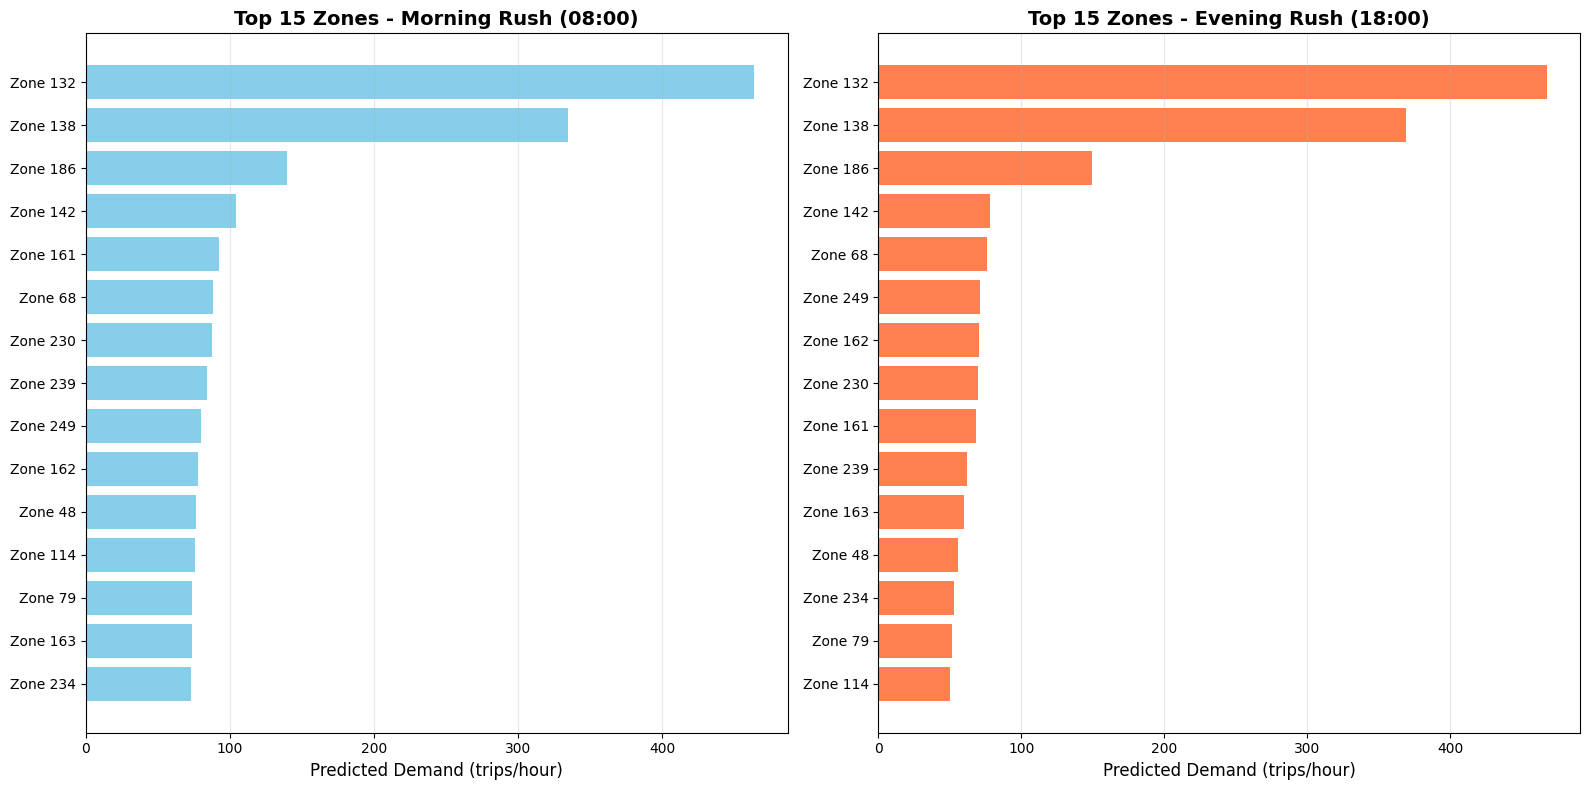


🔄 Predicting demand for next 24 hours...

🔮 Predicting demand for: 2026-01-25 00:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 01:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 02:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 03:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 04:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 05:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 06:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 07:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 08:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 09:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 10:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 11:00:00

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Morning hotspots
top_morning = hotspots_morning.head(15)
axes[0].barh(range(len(top_morning)), top_morning['predicted_demand'], color='skyblue')
axes[0].set_yticks(range(len(top_morning)))
axes[0].set_yticklabels([f"Zone {int(z)}" for z in top_morning['PULocationID']])
axes[0].set_xlabel('Predicted Demand (trips/hour)', fontsize=12)
axes[0].set_title(f'Top 15 Zones - Morning Rush ({tomorrow_8am.strftime("%H:%M")})', 
                  fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Evening hotspots
top_evening = hotspots_evening.head(15)
axes[1].barh(range(len(top_evening)), top_evening['predicted_demand'], color='coral')
axes[1].set_yticks(range(len(top_evening)))
axes[1].set_yticklabels([f"Zone {int(z)}" for z in top_evening['PULocationID']])
axes[1].set_xlabel('Predicted Demand (trips/hour)', fontsize=12)
axes[1].set_title(f'Top 15 Zones - Evening Rush ({tomorrow_6pm.strftime("%H:%M")})', 
                  fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/morning_vs_evening_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================

# Cell 8: Hourly Prediction for a Full Day (Next 24 Hours)
# Predict for every hour of tomorrow
tomorrow_start = datetime.now() + timedelta(days=1)
tomorrow_start = tomorrow_start.replace(hour=0, minute=0, second=0, microsecond=0)

hourly_predictions = []

print("\n🔄 Predicting demand for next 24 hours...")

for hour in range(24):
    target_time = tomorrow_start + timedelta(hours=hour)
    preds = predict_demand_for_datetime(model, target_time, historical_df, feature_names)
    
    # Get total predicted demand across all zones
    total_demand = preds['predicted_demand'].sum()
    
    hourly_predictions.append({
        'hour': hour,
        'datetime': target_time,
        'total_predicted_demand': total_demand,
        'top_zone': preds.iloc[0]['PULocationID'],
        'top_zone_demand': preds.iloc[0]['predicted_demand']
    })

hourly_pred_df = pd.DataFrame(hourly_predictions)

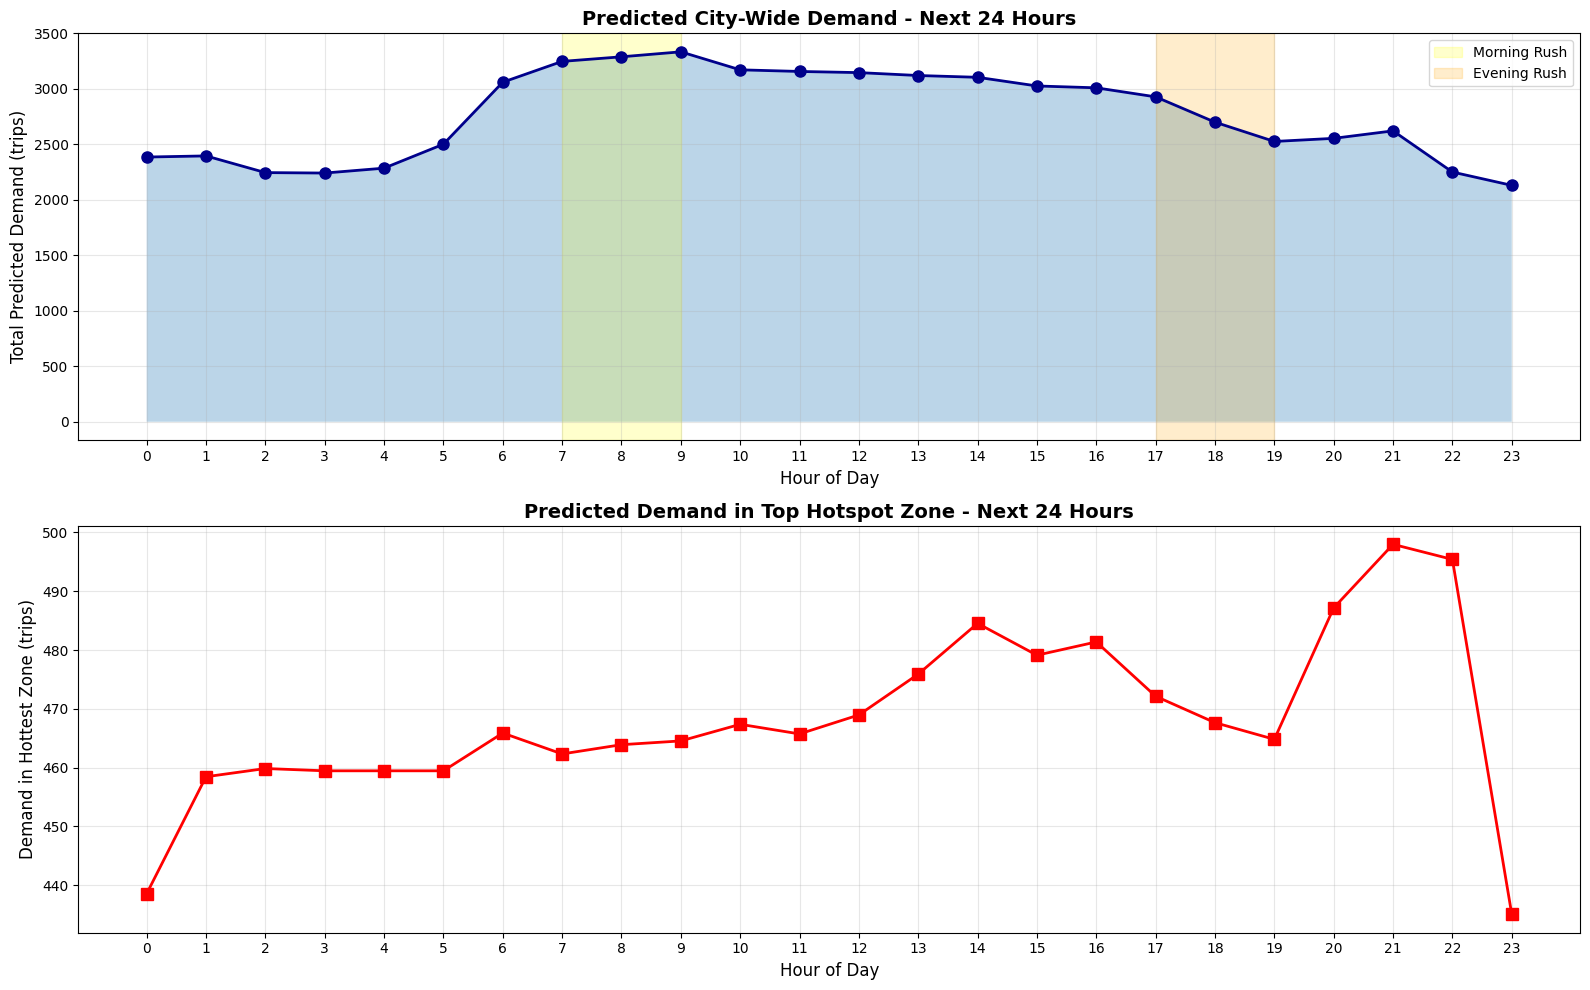


PEAK DEMAND PREDICTION
Peak demand hour: 9:00
Expected demand: 3334 trips
Hottest zone: 132


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Total city-wide demand
axes[0].plot(hourly_pred_df['hour'], hourly_pred_df['total_predicted_demand'], 
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0].fill_between(hourly_pred_df['hour'], hourly_pred_df['total_predicted_demand'], 
                      alpha=0.3)
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Total Predicted Demand (trips)', fontsize=12)
axes[0].set_title('Predicted City-Wide Demand - Next 24 Hours', 
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

# Add rush hour highlights
axes[0].axvspan(7, 9, alpha=0.2, color='yellow', label='Morning Rush')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
axes[0].legend()

# Hottest zone demand by hour
axes[1].plot(hourly_pred_df['hour'], hourly_pred_df['top_zone_demand'], 
             marker='s', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Demand in Hottest Zone (trips)', fontsize=12)
axes[1].set_title('Predicted Demand in Top Hotspot Zone - Next 24 Hours', 
                  fontsize=14, fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/24hour_demand_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PEAK DEMAND PREDICTION")
print("="*60)
peak_hour = hourly_pred_df.loc[hourly_pred_df['total_predicted_demand'].idxmax()]
print(f"Peak demand hour: {int(peak_hour['hour'])}:00")
print(f"Expected demand: {peak_hour['total_predicted_demand']:.0f} trips")
print(f"Hottest zone: {int(peak_hour['top_zone'])}")
print("="*60)


🔄 Creating zone-hour heatmap...

🔮 Predicting demand for: 2026-01-25 00:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 01:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 02:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 03:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 04:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 05:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 06:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 07:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 08:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 09:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 10:00:00
✅ Predictions complete for 212 zones

🔮 Predicting demand for: 2026-01-25 11:00:00
✅ Predic

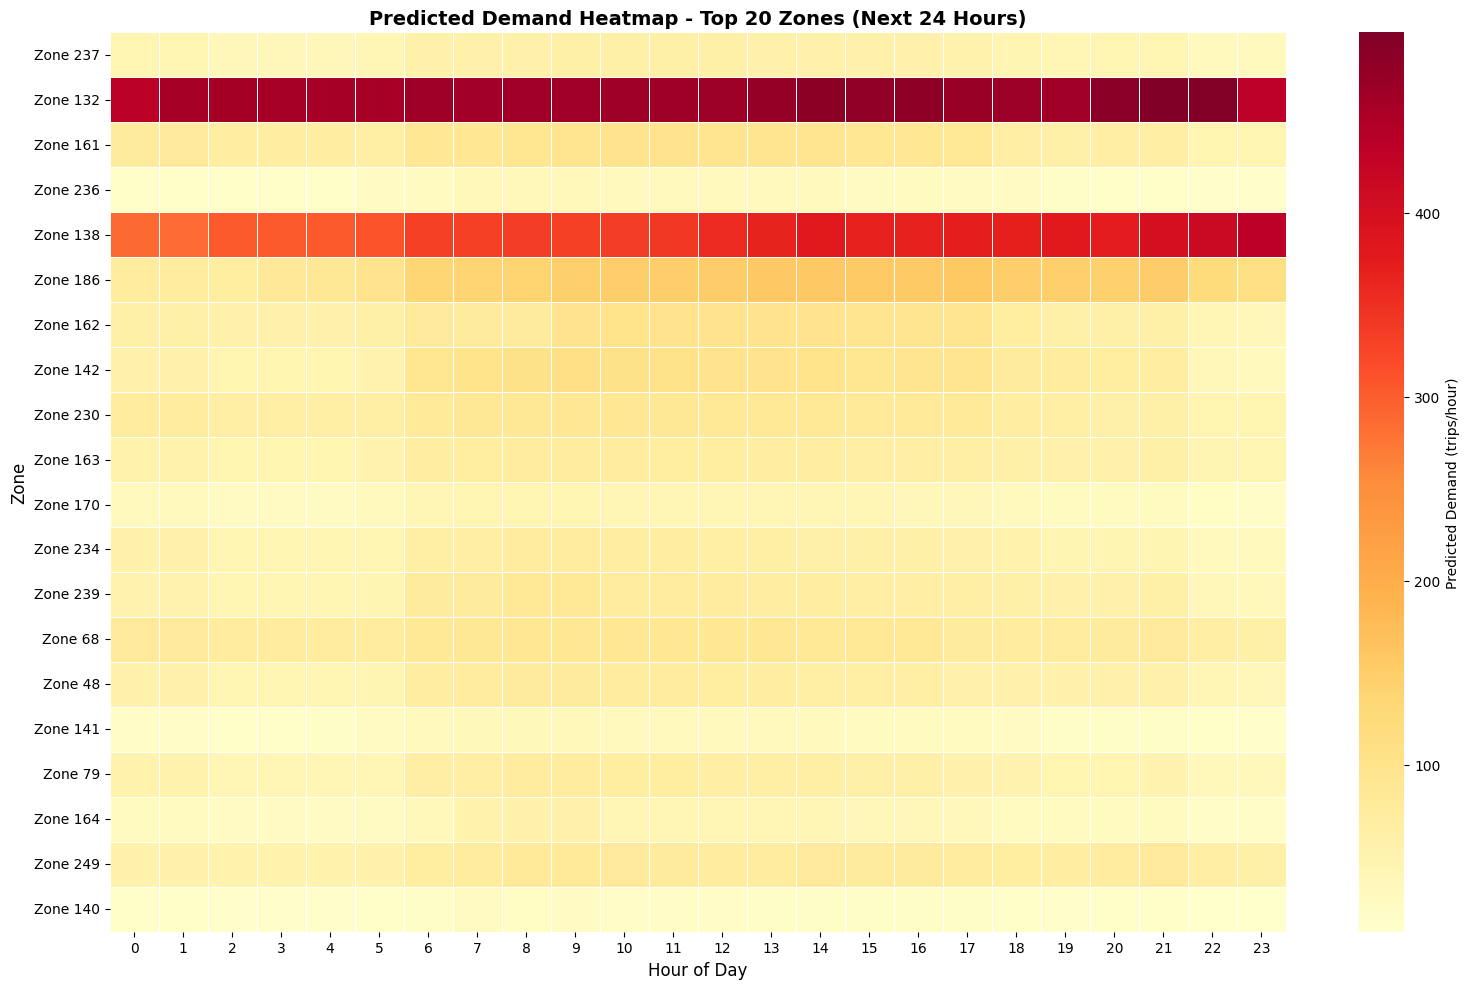

✅ Heatmap created!


In [12]:
print("\n🔄 Creating zone-hour heatmap...")

# Get top 20 zones by average demand
top_zones = historical_df.groupby('PULocationID')['demand'].mean().nlargest(20).index.tolist()

# Create matrix for heatmap
heatmap_data = []

for hour in range(24):
    target_time = tomorrow_start + timedelta(hours=hour)
    preds = predict_demand_for_datetime(model, target_time, historical_df, feature_names)
    
    # Get predictions for top zones
    zone_preds = preds[preds['PULocationID'].isin(top_zones)].set_index('PULocationID')
    zone_preds = zone_preds.reindex(top_zones)  # Ensure consistent order
    
    heatmap_data.append(zone_preds['predicted_demand'].values)

heatmap_matrix = np.array(heatmap_data).T

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_matrix, 
            xticklabels=range(24), 
            yticklabels=[f"Zone {int(z)}" for z in top_zones],
            cmap='YlOrRd', 
            cbar_kws={'label': 'Predicted Demand (trips/hour)'},
            linewidths=0.5)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Zone', fontsize=12)
plt.title('Predicted Demand Heatmap - Top 20 Zones (Next 24 Hours)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/zone_hour_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap created!")


In [13]:
hotspots_morning.to_csv('../outputs/reports/morning_hotspots.csv', index=False)

# Evening predictions
hotspots_evening.to_csv('../outputs/reports/evening_hotspots.csv', index=False)

# 24-hour forecast
hourly_pred_df.to_csv('../outputs/reports/24hour_forecast.csv', index=False)

print("\n✅ Predictions saved:")
print("  - outputs/reports/morning_hotspots.csv")
print("  - outputs/reports/evening_hotspots.csv")
print("  - outputs/reports/24hour_forecast.csv")


✅ Predictions saved:
  - outputs/reports/morning_hotspots.csv
  - outputs/reports/evening_hotspots.csv
  - outputs/reports/24hour_forecast.csv


In [14]:
def generate_driver_report(predictions_df, target_time, top_n=10):
    """Generate actionable recommendations for drivers"""
    
    report = f"""
{'='*70}
DRIVER POSITIONING RECOMMENDATIONS
{'='*70}
Target Time: {target_time.strftime('%A, %B %d, %Y at %H:%M')}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}

TOP {top_n} RECOMMENDED ZONES (Highest Predicted Demand):

"""
    
    for idx, row in predictions_df.head(top_n).iterrows():
        report += f"{idx+1:2d}. Zone {int(row['PULocationID']):3d} - Expected {row['predicted_demand']:5.1f} trips/hour\n"
    
    report += f"\n{'='*70}\n"
    report += f"AVOID THESE ZONES (Lowest Predicted Demand):\n\n"
    
    for idx, row in predictions_df.tail(5).iterrows():
        report += f"  Zone {int(row['PULocationID']):3d} - Expected {row['predicted_demand']:5.1f} trips/hour\n"
    
    report += f"{'='*70}\n"
    
    return report

# Generate reports
morning_report = generate_driver_report(hotspots_morning, tomorrow_8am)
evening_report = generate_driver_report(hotspots_evening, tomorrow_6pm)

print(morning_report)
print("\n")
print(evening_report)

# Save reports
with open('../outputs/reports/morning_recommendations.txt', 'w') as f:
    f.write(morning_report)

with open('../outputs/reports/evening_recommendations.txt', 'w') as f:
    f.write(evening_report)

print("\n✅ Driver recommendations saved to outputs/reports/")



DRIVER POSITIONING RECOMMENDATIONS
Target Time: Sunday, January 25, 2026 at 08:00
Generated: 2026-01-24 20:33:31

TOP 10 RECOMMENDED ZONES (Highest Predicted Demand):

98. Zone 132 - Expected 463.9 trips/hour
104. Zone 138 - Expected 334.5 trips/hour
146. Zone 186 - Expected 139.3 trips/hour
108. Zone 142 - Expected 104.4 trips/hour
125. Zone 161 - Expected  92.6 trips/hour
49. Zone  68 - Expected  88.0 trips/hour
182. Zone 230 - Expected  87.5 trips/hour
191. Zone 239 - Expected  84.0 trips/hour
199. Zone 249 - Expected  80.1 trips/hour
126. Zone 162 - Expected  78.1 trips/hour

AVOID THESE ZONES (Lowest Predicted Demand):

  Zone  36 - Expected   0.9 trips/hour
  Zone 149 - Expected   0.9 trips/hour
  Zone 193 - Expected   0.9 trips/hour
  Zone  21 - Expected   0.9 trips/hour
  Zone 248 - Expected   0.8 trips/hour




DRIVER POSITIONING RECOMMENDATIONS
Target Time: Sunday, January 25, 2026 at 18:00
Generated: 2026-01-24 20:33:31

TOP 10 RECOMMENDED ZONES (Highest Predicted Demand):


In [15]:
print("\n" + "="*70)
print("🎉 PREDICTION PIPELINE COMPLETE! 🎉")
print("="*70)
print("\nWhat you've accomplished:")
print("  ✅ Trained an XGBoost model on NYC taxi data")
print("  ✅ Created demand predictions for future times")
print("  ✅ Identified high-demand hotspots")
print("  ✅ Generated 24-hour demand forecasts")
print("  ✅ Created visualizations and reports")
print("\nYour outputs:")
print("  📊 Figures: outputs/figures/")
print("  📄 Reports: outputs/reports/")
print("  🤖 Model: models/")
print("\nNext steps for your project:")
print("  1. Create a web dashboard to display predictions")
print("  2. Add real-time data updates")
print("  3. Integrate with mapping APIs (Google Maps, Mapbox)")
print("  4. Deploy the model as an API")
print("  5. Add weather data for better predictions")
print("="*70)
print("\n💡 You now have a complete ML demand forecasting system!")
print("   Great job on your first ML project! 🚀")


🎉 PREDICTION PIPELINE COMPLETE! 🎉

What you've accomplished:
  ✅ Trained an XGBoost model on NYC taxi data
  ✅ Created demand predictions for future times
  ✅ Identified high-demand hotspots
  ✅ Generated 24-hour demand forecasts
  ✅ Created visualizations and reports

Your outputs:
  📊 Figures: outputs/figures/
  📄 Reports: outputs/reports/
  🤖 Model: models/

Next steps for your project:
  1. Create a web dashboard to display predictions
  2. Add real-time data updates
  3. Integrate with mapping APIs (Google Maps, Mapbox)
  4. Deploy the model as an API
  5. Add weather data for better predictions

💡 You now have a complete ML demand forecasting system!
   Great job on your first ML project! 🚀
